### Create a dataset with samples from three categories: coffee, tea, and water

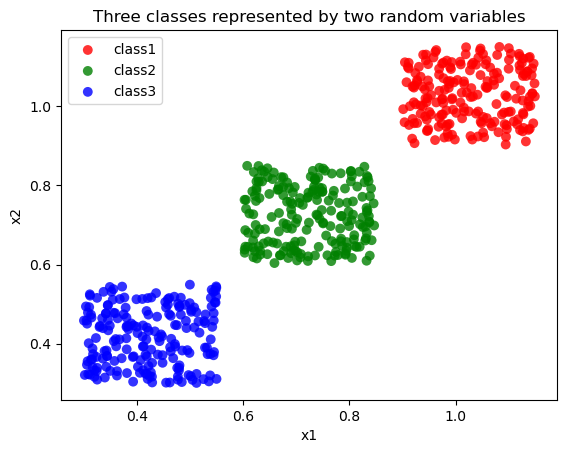

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator

# Create data
N  = 200
c1 = (0.90 + 0.25 * np.random.rand(N), 0.90 + 0.25*np.random.rand(N))
c2 = (0.60 + 0.25 * np.random.rand(N), 0.60 + 0.25*np.random.rand(N))
c3 = (0.30 + 0.25 * np.random.rand(N), 0.30 + 0.25*np.random.rand(N))

clusters = (c1, c2, c3)
colors   = ("red", "green", "blue")
classes  = ("class1", "class2", "class3")

# Create plot
fig = plt.figure()
ax  = fig.add_subplot(1, 1, 1)
ax.set_xlabel('x1')
ax.set_ylabel('x2')

for cluster, color, cls in zip(clusters, colors, classes):
    x1, x2 = cluster
    ax.scatter(x1, x2, alpha=0.8, c=color, edgecolors='none', s=50, label=cls)

plt.title('Three classes represented by two random variables')
plt.legend(loc=2)
plt.show()

### Separate the samples into training and testing sets

In [2]:
def UnisonShuffling(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X = [] 
Y = []
class1_size = len(c1[0])
for i in range(class1_size):
    X.append((c1[0][i],c1[1][i]))
    Y.append(0)  # class index for class1
class2_size = len(c2[0])
for i in range(class2_size):
    X.append((c2[0][i],c2[1][i]))
    Y.append(1)  # class index for class2
class3_size = len(c3[0])
for i in range(class3_size):
    X.append((c3[0][i],c3[1][i]))
    Y.append(2)  # class index for class3
nsamples = class1_size + class2_size + class3_size
X = np.array(X)
Y = np.array(Y)
# Apply shuffle and separate training and testing
Xaux = np.copy(X)
Yaux = np.copy(Y)
X, Y = UnisonShuffling(Xaux,Yaux) 
X_train = X[:nsamples//2]
Y_train = Y[:nsamples//2]
X_test  = X[nsamples//2:nsamples]
Y_test  = Y[nsamples//2:nsamples]

### Create a neural network model for classification and train it

In [3]:
import torch
from torch import nn as nn
import torch.optim as optim

# Define a MLP model with four neurons in the hidden layer and three neurons in the decision layer

class NeuralNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_features=2, out_features=4, bias=True),
            nn.ReLU(),
            nn.Linear(in_features=4, out_features=3, bias=True)
        )
        self.weights_init()

    def forward(self, x):
        y = self.classifier(x)
        return y

    def weights_init(self):
        for x in self.modules():
            if isinstance(x, nn.Linear):
                torch.nn.init.xavier_uniform_(x.weight.data)
                if (x.bias is not None): 
                    x.bias.data.zero_()

    
# Create the model with cross entropy loss and stochastic gradient descent optimizer

model     = NeuralNet()
print(model)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-1)

# Print weights and bias
print(model.classifier[0].weight, model.classifier[0].bias)
print(model.classifier[2].weight, model.classifier[2].bias)

NeuralNet(
  (classifier): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=3, bias=True)
  )
)
Parameter containing:
tensor([[ 0.0602, -0.6501],
        [ 0.7006, -0.3199],
        [ 0.2837, -0.6984],
        [-0.7650, -0.4321]], requires_grad=True) Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
Parameter containing:
tensor([[-0.2750, -0.5277,  0.2773, -0.4543],
        [ 0.9165, -0.4886,  0.2459,  0.0803],
        [-0.3837,  0.4415,  0.1188, -0.2653]], requires_grad=True) Parameter containing:
tensor([0., 0., 0.], requires_grad=True)


### A suitable weight initialization can speed up convergence. We can set the weights of the four neurons in the first layer as follows. 

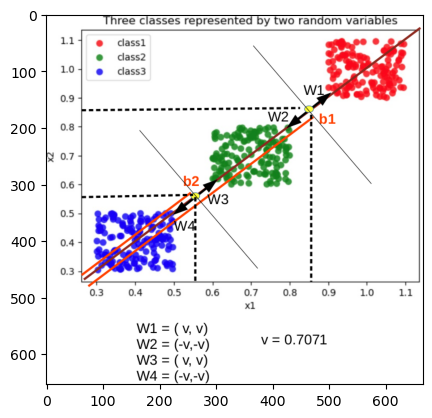

In [4]:
fig = plt.imread('../figs/simple-classification.png')
plt.imshow(fig)
plt.show()

In [5]:
# You can set the weights W1, W2, W3, W4 (orthogonal vectors of the class separation lines above)
# and the biases based on the distances b1 and b2 to the origin. Note that, the NN performs 
# <(x1,x2),Wi> + bias, i=1,2,3,4, then the bias must be -b1 for W1, b1 for W2, -b2 for W3, and b2 for W4. 
# The following lines do that and freeze the dense layer for the training process. If you comment those lines, 
# the training process will estimate the weights of the hidden layer. 

v       = (2.0**0.5)/2
b1      = ((0.85)**2 + (0.85)**2)**0.5
b2      = ((0.55)**2 + (0.55)**2)**0.5
weights = np.array([[v, v], [-v, -v], [v, v], [-v, -v]])
bias    = np.array([-b1, b1, -b2, b2])

# Convert from numpy to tensor
weights = nn.Parameter(torch.from_numpy(weights).float())
bias    = nn.Parameter(torch.from_numpy(bias).float())

# Set weights and bias of the first hidden layer
model.classifier[0].weight.data  = weights
model.classifier[0].bias.data    = bias

# Freeze first hidden layer
for param in model.classifier[0].parameters():
    param.requires_grad = False
    
# Print weights and bias
print(model.classifier[0].weight, model.classifier[0].bias)
print(model.classifier[2].weight, model.classifier[2].bias)    

Parameter containing:
tensor([[ 0.7071,  0.7071],
        [-0.7071, -0.7071],
        [ 0.7071,  0.7071],
        [-0.7071, -0.7071]]) Parameter containing:
tensor([-1.2021,  1.2021, -0.7778,  0.7778])
Parameter containing:
tensor([[-0.2750, -0.5277,  0.2773, -0.4543],
        [ 0.9165, -0.4886,  0.2459,  0.0803],
        [-0.3837,  0.4415,  0.1188, -0.2653]], requires_grad=True) Parameter containing:
tensor([0., 0., 0.], requires_grad=True)


### Train the model

Parameter containing:
tensor([[ 0.7071,  0.7071],
        [-0.7071, -0.7071],
        [ 0.7071,  0.7071],
        [-0.7071, -0.7071]]) Parameter containing:
tensor([-1.2021,  1.2021, -0.7778,  0.7778])
Parameter containing:
tensor([[ 0.1735, -1.1339,  1.2142, -0.5788],
        [ 0.6231, -0.6413, -0.0059, -0.0768],
        [-0.5388,  1.2005, -0.5663,  0.0163]], requires_grad=True) Parameter containing:
tensor([ 0.0157,  0.1084, -0.1240], requires_grad=True)
Train loss = 0.7268, Train acc = 0.6867


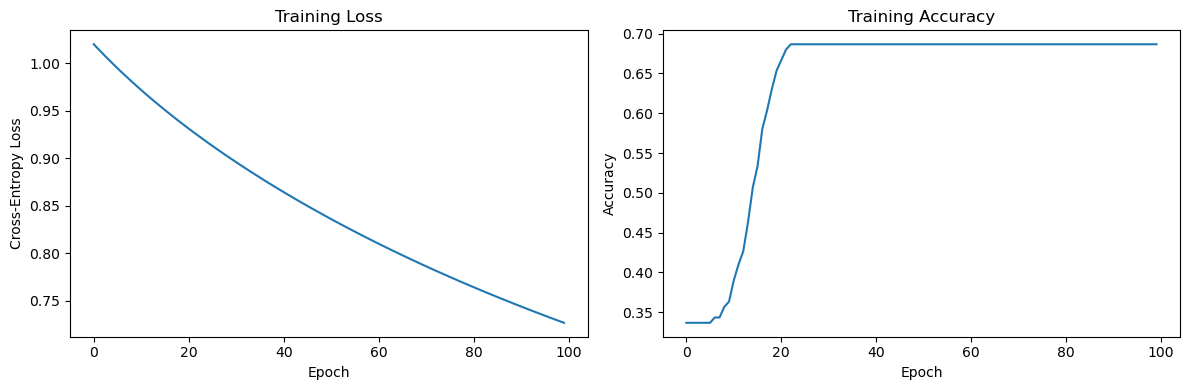

In [6]:
# Convert the training set from numpy to tensor

X_train = torch.FloatTensor(X_train)
Y_train = torch.LongTensor(Y_train)  # class indices for CrossEntropyLoss

# Train the model

model.train()
epochs   = 100 # if you increase it, then the convergence happens even without forcing the above initialization
losses   = []
accs     = []

for epoch in range(epochs):
    optimizer.zero_grad() # set gradients to zero
    # Forward pass
    y_pred   = model(X_train) 
    corrects = torch.sum(torch.argmax(y_pred, dim=1) == Y_train).item()
    n        = y_pred.size(0)
    # Compute Loss
    loss = criterion(y_pred.squeeze(), Y_train)
    losses.append(loss.item())
    accs.append(corrects / n)
    # Backward pass
    loss.backward()
    optimizer.step()
    
# Print weights and bias
print(model.classifier[0].weight, model.classifier[0].bias)
print(model.classifier[2].weight, model.classifier[2].bias)    

# Accuracy after the last epoch    
print(f'Train loss = {losses[-1]:.4f}, Train acc = {accs[-1]:.4f}')

# Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')

ax2.plot(accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')

plt.tight_layout()
plt.show()

### Evaluate the model 

In [7]:
# Convert the test set from numpy to tensor

X_test = torch.FloatTensor(X_test)
Y_test = torch.LongTensor(Y_test)  # class indices

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred   = model(X_test)
    loss     = criterion(y_pred.squeeze(), Y_test)
    corrects = torch.sum(torch.argmax(y_pred, dim=1) == Y_test).item()
    n        = y_pred.size(0)
    print(f'Test loss = {loss.item():.4f}, Test acc = {corrects/n:.4f}')

Test loss = 0.7467, Test acc = 0.6467
